# Generic Optimizer Tutorial

**cyopt** is a discrete optimization toolkit for bounded integer-tuple search spaces.
It ships 8 optimizers that all share the same simple interface:

| Optimizer | Strategy |
|-----------|----------|
| `GA` | Genetic algorithm with configurable selection, crossover, and mutation |
| `RandomSample` | Uniform random sampling -- the simplest baseline |
| `GreedyWalk` | Hill-climbing walk through the neighbour graph |
| `BestFirstSearch` | Priority-queue search with backtrack or frontier modes |
| `BasinHopping` | Perturbation + greedy descent with Metropolis acceptance |
| `DifferentialEvolution` | SciPy wrapper with native integer support |
| `MCMC` | Metropolis--Hastings on integer tuples |
| `SimulatedAnnealing` | Exponential cooling with Boltzmann acceptance |

This tutorial walks through the common workflow: define an objective, run an
optimizer, inspect convergence, compare algorithms, and use callbacks and
checkpoints.  No CYTools dependency is needed -- everything here runs on
plain integer tuples.

## Setup and Test Function

We start by importing the optimizers and defining a simple objective: the
*integer sphere function* $f(\mathbf{x}) = \sum_i x_i^2$, which has a global
minimum of 0 at the origin.

In [1]:
from cyopt import (
    GA, RandomSample, GreedyWalk, BestFirstSearch,
    BasinHopping, DifferentialEvolution, MCMC, SimulatedAnnealing,
    Bounds, CheckpointCallback, TupleSpace,
)
import matplotlib.pyplot as plt
import numpy as np
print("cyopt loaded successfully")

cyopt loaded successfully


In [2]:
def sphere(x):
    """Integer sphere function: minimize sum of squares."""
    return sum(xi**2 for xi in x)

ndim = 10
bounds = tuple((0, 20) for _ in range(ndim))
space = TupleSpace(bounds)
print(f"Search space: {ndim} dimensions, each in [0, 20]")
print(f"Total grid points: {21**ndim:,}")

Search space: 10 dimensions, each in [0, 20]
Total grid points: 16,679,880,978,201


## Running a Single Optimizer

Every optimizer follows the same pattern:
1. Instantiate with a fitness function and bounds.
2. Call `.run(n_iterations)` to get a `Result`.

Let's start with the **Genetic Algorithm**.

In [3]:
ga = GA(sphere, space, seed=42)
result = ga.run(200)

print(f"Best solution: {result.best_solution}")
print(f"Best value:    {result.best_value}")
print(f"Evaluations:   {result.n_evaluations}")
print(f"Wall time:     {result.wall_time:.3f}s")

Best solution: (0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
Best value:    0
Evaluations:   2747
Wall time:     0.385s


## Convergence Plot

`result.history` records the best-so-far fitness value at each iteration,
making it easy to visualise convergence.

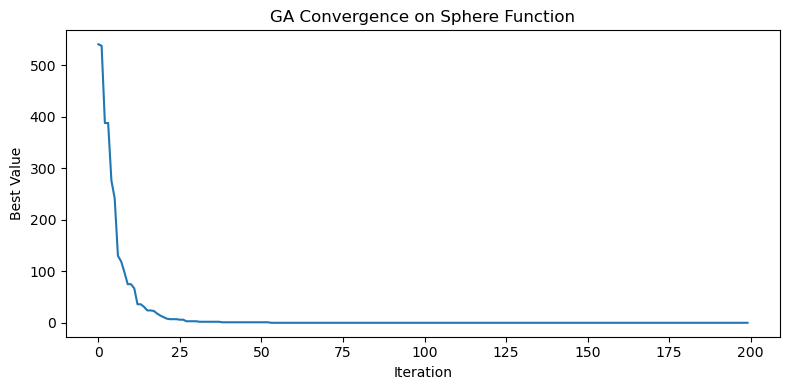

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(result.history)
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.title("GA Convergence on Sphere Function")
plt.tight_layout()
plt.show()

## Comparing Optimizers

One of cyopt's strengths is that all 8 optimizers share the same constructor
interface.  We can run them all on the same problem and compare.

In [5]:
optimizers = {
    "GA": GA(sphere, space, seed=42),
    "RandomSample": RandomSample(sphere, space, seed=42),
    "GreedyWalk": GreedyWalk(sphere, space, seed=42),
    "BestFirstSearch": BestFirstSearch(sphere, space, seed=42),
    "BasinHopping": BasinHopping(sphere, space, seed=42),
    "DiffEvolution": DifferentialEvolution(sphere, space, seed=42),
    "MCMC": MCMC(sphere, space, seed=42),
    "SimAnnealing": SimulatedAnnealing(sphere, space, seed=42),
}

results = {}
for name, opt in optimizers.items():
    results[name] = opt.run(200)
    print(f"  {name}: done")

  GA: done
  RandomSample: done
  GreedyWalk: done


  BestFirstSearch: done
  BasinHopping: done


  DiffEvolution: done
  MCMC: done
  SimAnnealing: done


In [6]:
print(f"{'Optimizer':<18} {'Best Value':>10} {'Evaluations':>12} {'Time (s)':>10}")
print("-" * 52)
for name, r in sorted(results.items(), key=lambda x: x[1].best_value):
    print(f"{name:<18} {r.best_value:>10.1f} {r.n_evaluations:>12} {r.wall_time:>10.3f}")

Optimizer          Best Value  Evaluations   Time (s)
----------------------------------------------------
GA                        0.0         2747      0.383
GreedyWalk                0.0        31886      0.118
BestFirstSearch           0.0        26824      0.095
BasinHopping              0.0        17354      0.145
DiffEvolution             0.0        10467      0.419
SimAnnealing              3.0          191      0.001
MCMC                      5.0          194      0.001
RandomSample            537.0          200      0.003


## Convergence Comparison Plot

Plotting all convergence curves together shows how different strategies
explore the search space.

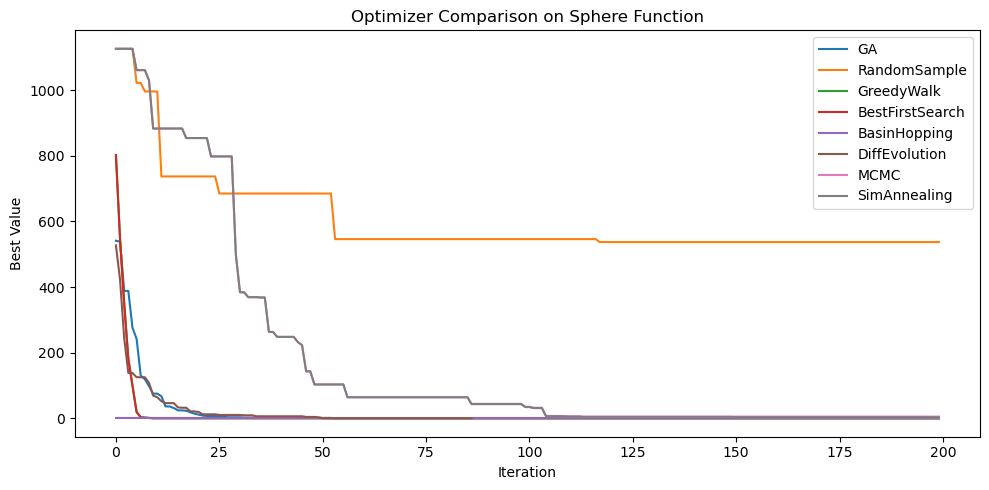

In [7]:
plt.figure(figsize=(10, 5))
for name, r in results.items():
    plt.plot(r.history, label=name)
plt.xlabel("Iteration")
plt.ylabel("Best Value")
plt.title("Optimizer Comparison on Sphere Function")
plt.legend()
plt.tight_layout()
plt.show()

## Callbacks and Early Stopping

Callbacks are functions passed to the optimizer constructor that are called
after each iteration.  They receive a dict with keys `iteration`,
`best_value`, `best_solution`, `n_evaluations`, and `wall_time`.

- Return `None` (or nothing) to continue.
- Return `True` to trigger early stopping.

In [8]:
def log_callback(info):
    """Print progress every 50 iterations."""
    if info["iteration"] % 50 == 0:
        print(f"  Iter {info['iteration']:>4d}: best = {info['best_value']:.1f}")
    return None

def stop_at_zero(info):
    """Stop early if we reach the global minimum."""
    if info["best_value"] == 0:
        print(f"  Optimal found at iteration {info['iteration']}!")
        return True
    return None

ga2 = GA(sphere, space, seed=42, callbacks=[log_callback, stop_at_zero])
result2 = ga2.run(500)
print(f"\nStopped after {len(result2.history)} iterations, best = {result2.best_value}")

  Iter    0: best = 541.0
  Iter   50: best = 1.0
  Optimal found at iteration 53!

Stopped after 54 iterations, best = 0


## Checkpoint and Resume

For long-running optimizations you can save checkpoints to disk and resume
later.  `CheckpointCallback` saves state every N iterations.  To resume,
call `Optimizer.load_checkpoint(path, fitness_fn)` and then `.run()` again.

> **Note:** The fitness function is not stored in the checkpoint (it may
> reference external state), so you must pass it again when loading.

In [9]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    ckpt_path = os.path.join(tmpdir, "checkpoint.pkl")

    cb = CheckpointCallback(path=ckpt_path, every_n=50)
    ga3 = GA(sphere, space, seed=42, callbacks=[cb])
    result3 = ga3.run(100)
    print(f"After 100 iters: best = {result3.best_value}")

    # Resume from checkpoint
    ga4 = GA.load_checkpoint(ckpt_path, sphere)
    result4 = ga4.run(100)
    print(f"After 100 more:  best = {result4.best_value}")

After 100 iters: best = 0
After 100 more:  best = 0


## Extending a Run

You don't always need checkpoints to continue optimizing.  Since optimizers
maintain their internal state, you can simply call `.run()` again on the
same object to pick up where you left off.

In [10]:
ga5 = GA(sphere, space, seed=42)
r1 = ga5.run(100)
print(f"After 100 iters: best = {r1.best_value}")

r2 = ga5.run(100)  # continues from iteration 100
print(f"After 200 iters: best = {r2.best_value}")

After 100 iters: best = 0
After 200 iters: best = 0
